# Efficient Simulation of Stochastic Reaction Networks
## Michaelis–Menten SRN

**DISCLAIMER:**

FUNCTION DEFINITIONS, EXPLANATION AND COMMENTS OF THE CODE HAVE BEEN ENTIRELY WRITTEN BY US.
AI USAGE IS LIMITED TO PLOTS PRODUCTION AND FASTER INTERPRETATION OF THE ERRORS IN THE DEBUGGING PHASE.

For explanations and comments on the results see the project report file.

## SSA definition

In [1]:
import numpy as np
import scipy.stats as st
import scipy.optimize as so
import matplotlib.pyplot as plt
import math as m

## general setting of the system 
#NR = 3              # Number of Reactions
#NS = 4              # Number of Species 
alpha = np.array([[1,1,0,0],[0,0,1,0],[0,0,1,0]])   # values from the physical system
beta = np.array([[0,0,1,0],[1,1,0,0],[0,1,0,1]])    # values from the physical system
##

## setting for part 2.1
c = np.array([0.0017, 10**-4, 0.1])                 # constant values given in proj. descr.  
X = np.array([312, 125, 0, 0], dtype=int)           # initial states of the four species
t = 0                                               # initial time
T = 50                                              # final time
##


### functions defintion for the stochastic simulation of the Michaelis–Menten system

def propensity(X,c,alpha):
    """
    input: 
        X       : current states (vector of dim=num_species of INTEGERS)
        c       : (vector of constants with dim=num_reactions)
        alpha   : (coeff of the left side of the system).
    output: 
        a       : propensity function (vector of dim=num_reactions)
    explanation:  
        compute the formula given in the project description for integers X_i
    """

    # if there is at least one species in enough quantity for one reaction, this is well defined
    a = np.array(c)
    for j in range(0,len(c)):
        for i in range(0,len(X)):
            if X[i]>=alpha[j][i]:
                a[j] = a[j]*m.perm(X[i],alpha[j][i])
            else:
                a[j] = 0    #if there is just one no enough Species for some reaction, that cannot happen

    return a

def sim_step_SSA(X,t,T,c,alpha,beta):
    """
    input: 
        X       : current states (vector of dim=num_species) 
        t       : initial time
        T       : final time (last t is > T) 
        c       : (vector of constants with dim=num_reactions) 
        alpha   : (coeff of the left side of the system)
        beta    : (coeff of the right side of the system)
    output: 
        X_next  : states after one step(vector of dim=num_reactions) 
        t_next  : time at which next reaction happen
    explanation: 
        do a step of the simulation accordingly to Algorithm 1 of proj. descr.
    """

    a = propensity(X,c,alpha)
    a_sum = sum(a)
    if a_sum == 0:
        ### comment the print when running multiple simulations for estimations ###
        #print(f"At this this state, no reaction can happen. Equilibrium reached at time {t}")
        return X, T
    pmf = a/a_sum               #pmf of j-th reaction to happen 

    I = np.random.choice(np.arange(len(c)),p=pmf)   # sample of the next reaction to happen
    tau = np.random.exponential(1/a_sum)        # sample the time for the next reaction
    nu_I = beta[I]-alpha[I]                     # stochiometric vector associated to reaction I

    X_next = X + nu_I
    t_next = t + tau

    return X_next, t_next

# general simulation function
def simulation(sim_step,X,t,T,*step_args,max_iter=10**5):
    """
    input: 
        sim_step    : function of the simulation step, depends on numerical algorithm to use
                      sim_step HAS TO take in input (X,t,T, ...)
        X           : initial states (vector of dim=num_species) 
        t           : initial time
        T           : approx final time (last t is > T) 
        step_args   : all the other ordered inputs needed for sim_step except for X,t,T
        max_iter    : max number of iteration of sim_step 
    output: 
        X_evo   : evolution of all the states (matrix of dim = num_time_steps * num_reactions), 
        t_evo   : time steps (vector dim=num_time_steps)
    explanation: 
        run a simulation of the reactions in according with the algorithm implemented in the 
        simulation step. Use of "while" loop because time step is not always constant so the 
        number of steps is not known a priori. N.B. X,t,T are not in *step_args because they
        are used also for the external loop.
    """
    
    t_current = t
    X_current = X
    t_evo = [t]
    X_evo = X
    iter_count = 0
    while t_current < T and iter_count < max_iter:
        X_current, t_current = sim_step(X_current,t_current,T,*step_args)
        t_evo.append(t_current)
        X_evo = np.vstack([X_evo, X_current])
        iter_count += 1
    
    if iter_count == max_iter and t_current < T:
        raise RuntimeError("error in simulation loop: max iteration reached before final time")

    return X_evo, t_evo

###

### Plots with SSA (S-2.1/G-2)


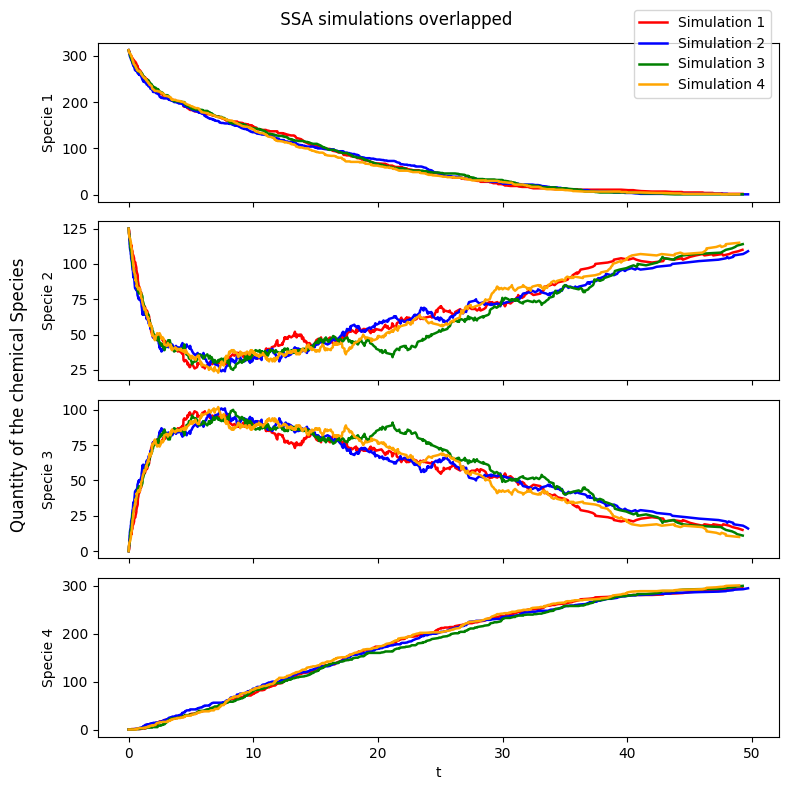

In [ ]:
## section 2.1 - goal 2.2 

n_sims = 4
sim_colors = ['r', 'b', 'g', 'orange']  

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8))

fig.supylabel("Quantity of the chemical Species")

for k in range(n_sims):
    X_try, t_try = simulation(sim_step_SSA, X, t, T, c, alpha, beta)

    #remove last element of t and X because if Equilibrium is reached at t_eq << T, the plot will have 
    #a constant line from t_eq to T, making the plot uncomfrotable to reed

    t_plot = t_try[:-1]
    X_plot = X_try[:-1, :]   

    for i in range(4):
        axes[i].plot(
            t_plot,
            X_plot[:, i],
            color=sim_colors[k],
            linewidth=1.8,
            label=f"Simulation {k+1}"
        )

# labels
for i in range(4):
    axes[i].set_ylabel(f"Specie {i+1}")
axes[-1].set_xlabel("t")

fig.suptitle(" SSA simulations overlapped")

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.99))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.tight_layout()
#plt.savefig("SSA_sim.png", dpi=300, bbox_inches="tight") #only to save for the report
plt.show()


## Crude Monte Carlo definition

In [3]:
## Generic Crude Monte Carlo function useful for successive tasks

def CMC(sig_lev, qoi, N, simulate, *sim_args ):
    """
    input:
        sig_lev  : significance level (alpha) for CI
        qoi      : quantity of interest to be estimated (function of one simulation result (X,t))
        N        : population (number of simulations) 
        simulate : simulation function to compute data for estimation
        sim_args : all positional arguments needed for simulation function
    output:
        Z        : estimation of the quantity of interest
        var_est  : Variance of the estimator 
        CI       : Confidence Interval
        obs      : number of observation of the qoi (Only for true/false qoi)
    explanation: 
        compute the value of the estimator for the quantity of interest taken from a generic kind of 
        simulation with its confidence interval wr to the significance level
    """
    samples = []

    for k in range(N):
        X_evo, t_evo = simulate(*sim_args)
        samples.append(qoi(X_evo, t_evo))

    samples = np.array(samples)
    obs = sum(samples)
    Z = samples.mean()                     
    se = samples.std(ddof=1) / np.sqrt(N)    # standard error = sqrt(Var(est))
    var_est = se**2                          # Var(est)

    q = st.norm.ppf(1 - sig_lev/2)           # alpha-quantile of normal distribution
    CI = (Z - q*se, Z + q*se)

    return Z, var_est, CI, obs

##

### CMC experiment (S-2.1/G-3)

In [4]:
## Section 2.1 goal 3

def S4_final(X_evo, t_evo):
    """
    input:
        X_evo           : evolution of all the species of the system
        t_evo           : discrete times of the evolution (just to be consistent with CMC function)
    output: 
        X_evo[-1, 3]    : last value of the specie S4
    explanetion:
        take the last value of S4 ASSUMING that the last value of t_evo is T or very close to T;
        This is to compute the MC estimator of S_4(T)
    """
    return X_evo[-1, 3]


In [ ]:

sig_lev = 0.05          # fixed
N = 10
N_steps = 1
max_N = 10000           # to avoid infinite loop
eps = 1                 # threshold for half-width of the confidence interval
half_width_CI = eps+1

# To save values for the plot 
N_hist = []
Z_hist = []
CI_lo_hist = []
CI_hi_hist = []

while half_width_CI > eps and N < max_N:
    Z, var_z, CI, _ = CMC(sig_lev, S4_final, N, simulation, sim_step_SSA, X, t, T, c, alpha, beta)
    half_width_CI = (CI[1]-CI[0])/2

    N_hist.append(N)
    Z_hist.append(Z)
    CI_lo_hist.append(CI[0])
    CI_hi_hist.append(CI[1])

    N += N_steps
    # print(f"quantity of interest observed {obs} times in {N} simulations")

print(f"Z=E[S4(T)]={Z} with CI=({CI[0]},{CI[1]}) and Var(Z)={var_z} after N={N-N_steps} simulations")

##

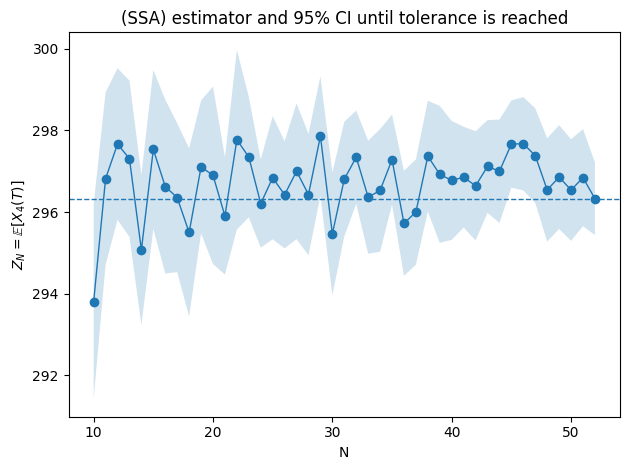

In [ ]:
# plot of the estimator values computed with its CI w.r. N until tollerance reached

N_arr = np.array(N_hist)
Z_arr = np.array(Z_hist)
CI_lo_arr = np.array(CI_lo_hist)
CI_hi_arr = np.array(CI_hi_hist)

plt.figure()
plt.plot(N_arr, Z_arr, marker='o', linewidth=1)
plt.fill_between(N_arr, CI_lo_arr, CI_hi_arr, alpha=0.2)
plt.axhline(Z_arr[-1], linewidth=1, linestyle='--')  # reference line (last value)
plt.xlabel("N")
plt.ylabel(r"$ Z_N = {\mathbb{E}}[X_4(T)]$")
plt.title("(SSA) estimator and 95% CI until tolerance is reached")
plt.tight_layout()
#plt.savefig("SSA_MC_N.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Produce values of the estimator with its CI w.r. N for the plot
N_big_max = 10000      
N_big_step = 500       
N_tol = 500

N_big_hist = []
Z_big_hist = []
CI_big_lo = []
CI_big_hi = []

for N_big in range(N_tol, N_big_max + 1, N_big_step):
    Zb, varb, CIb, _ = CMC(sig_lev, S4_final, N_big, simulation, sim_step_SSA, X, t, T, c, alpha, beta)

    N_big_hist.append(N_big)
    Z_big_hist.append(Zb)
    CI_big_lo.append(CIb[0])
    CI_big_hi.append(CIb[1])



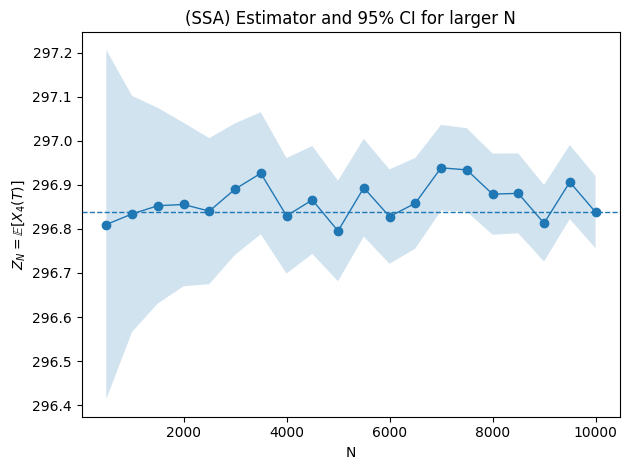

In [ ]:
# plot of the estimator vs large N
N_big_arr = np.array(N_big_hist)
Z_big_arr = np.array(Z_big_hist)
CI_big_lo_arr = np.array(CI_big_lo)
CI_big_hi_arr = np.array(CI_big_hi)

plt.figure()
plt.plot(N_big_arr, Z_big_arr, marker='o', linewidth=1)
plt.fill_between(N_big_arr, CI_big_lo_arr, CI_big_hi_arr, alpha=0.2)
plt.axhline(Z_big_arr[-1], linewidth=1, linestyle='--')  # last value as reference
plt.xlabel("N")
plt.ylabel(r"$ Z_N = {\mathbb{E}}[X_4(T)]$")
plt.title("(SSA) Estimator and 95% CI for larger N")
plt.tight_layout()
#plt.savefig("SSA_MC_large_N.png", dpi=300, bbox_inches="tight")
plt.show()


### CMC experiment (S-2.1/G-4)

In [27]:
## section 2.1 goal 4

# settings for this part
c = np.array([0.001, 0.005, 0.01])                  # constant values given in proj. descr.  
X = np.array([100, 100, 0, 0], dtype=int)           # initial states of the four species
t = 0                                               # initial time
T = 1                                               # final time
#

def S3_final_constraint(X_evo, T_evo):
    """
    input:
        X_evo               : evolution of all the species of the system
        t_evo               : discrete times of the evolution (just to be consistent with CMC function)
    output: 
        X_evo[-1, 2] > 22   : return 1 if S3(T)>22, 0 otherwise
    explanetion:
        take the last value of S3 ASSUMING that the last value of t_evo is T or very close to T 
        and return 1 if S3(T)>22, 0 otherwise; This is to compute the MC estimator of Chi(S3(T)>22)
    """
    return X_evo[-1, 2] > 22

N_values = [10, 100, 1000, 10000, 100000]
sig_lev = 0.05

for N in N_values:
    Z, var_z, _, obs = CMC(sig_lev, S3_final_constraint, N, simulation, sim_step_SSA, X, t, T, c, alpha, beta)
    print(f"Z=E[\Chi(S3(T)>22)]={Z} has Variance Var(Z)={var_z} for N={N} simulations ({obs} observations)")

##

Z=E[\Chi(S3(T)>22)]=0.0 has Variance Var(Z)=0.0 for N=10 simulations (0 observations)
Z=E[\Chi(S3(T)>22)]=0.0 has Variance Var(Z)=0.0 for N=100 simulations (0 observations)
Z=E[\Chi(S3(T)>22)]=0.0 has Variance Var(Z)=0.0 for N=1000 simulations (0 observations)
Z=E[\Chi(S3(T)>22)]=0.0 has Variance Var(Z)=0.0 for N=10000 simulations (0 observations)
Z=E[\Chi(S3(T)>22)]=2e-05 has Variance Var(Z)=1.9999799997999985e-10 for N=100000 simulations (2 observations)


## Importance Sampling definition

In [ ]:
## Section 2.1 goal 5 -- construction of an Importance Sampling function

def weight_func_SSA(X_evo, t_evo, T, c, c_tilde, alpha, beta):
    """ 
    input:
        X_evo   : evolution of the species of one simulation runned wr to c_tilde
        t_evo   : evolution of time of one simulation runned wr to c_tilde
        T       : final time
        c       : parameter of the propensity of the original phenomena
        c_tilde : modified parameter of the ppropensity for the dominating distr. for IS
        alpha   : (coeff of the left side of the system)
        beta    : (coeff of the right side of the system)
    output:
        w       : weight function for IS evaluated for the input sim
    explanation:
        compute the value of the weight function for the importance sampling through 
        the analytical expression derived in the case of a !SSA algortihm! for a certain 
        simulation. The expression is derived computing the likelihood functions of a general
        chain produced by the standard distribution (with parameter c) and by the dominating
        one (with parameter c_tilde), evaluating both of them in the chain produced by the 
        dominating distribution and making the ratio. Therefore, X_evo and t_evo have to be
        produced in the c_tilde case.  
    """
    t = t_evo[:-1] + [T] 
    X = np.vstack((X_evo[:-1], X_evo[-2]))

    w = 0
    for i in range(0,len(t)-1):
        a_c_tilde = propensity(X[i], c_tilde, alpha)
        a_c_tilde_sum = sum(a_c_tilde)
        a_c = propensity(X[i],c,alpha)
        a_c_sum = sum(a_c)
        for J in range(0,len(c)):
            if np.array_equal(X[i+1] - X[i], beta[J] - alpha[J]):
                break
        
        w += (np.log(a_c[J])-np.log(a_c_tilde[J]))*(i < (len(t)-2)) - (a_c_sum-a_c_tilde_sum)*(t[i+1]-t[i])

    return np.exp(w)

def IS(c_tilde, sig_lev, qoi, N, simulate, *sim_args, index_c = -3):
    """
    input:
        c_tilde  : c parameters for the dominating distribution 
        sig_lev  : significance level (alpha) for CI
        qoi      : quantity of interest to be estimated (function of one simulation result (X,t))
        N        : population (number of simulations) 
        simulate : simulation function to compute data for estimation
        sim_args : all positional arguments needed for simulation function 
    output:
        Z_IS     : estimation of the quantity of interest with Importance Sampling
        var_Z_IS : Variance of the estimator with Importance Sampling
        CI_IS    : Confidence Interval
        obs      : number of observations of qoi (Only for True/False qoi)
    explanation: 
        compute the value of the estimator for the quantity of interest taken from a generic kind of 
        simulation with its confidence interval wr to the significance level through Importance Sampling
        based on g (dominating distribution) computed with c_tilde instead of c. 
        N.B. we are assuming that alpha and beta are always the last two elements of sim_args.       
    """

    sim_args_tilde = (*sim_args[0:index_c], c_tilde, *sim_args[index_c+1:])
    c = sim_args[index_c]
    T = sim_args[3]
    alpha = sim_args[-2]
    beta = sim_args[-1]

    samples = []
    obs_vector = []

    for k in range(N):
        X_evo, t_evo = simulate(*sim_args_tilde)
        w = weight_func_SSA(X_evo, t_evo, T, c, c_tilde, alpha, beta)
        obs_vector.append(qoi(X_evo, t_evo))
        samples.append(qoi(X_evo, t_evo)*w)

    samples = np.array(samples)
    obs = sum(obs_vector)
    Z_IS = samples.mean()                     
    se = samples.std(ddof=1) / np.sqrt(N)    # standard error = sqrt(Var(est))
    var_Z_IS = se**2                          # Var(est)

    q = st.norm.ppf(1 - sig_lev/2)           # alpha-quantile of normal distribution
    CI_IS = (Z_IS - q*se, Z_IS + q*se)

    return Z_IS, var_Z_IS, CI_IS, obs

##

### Studying new c tilde parms

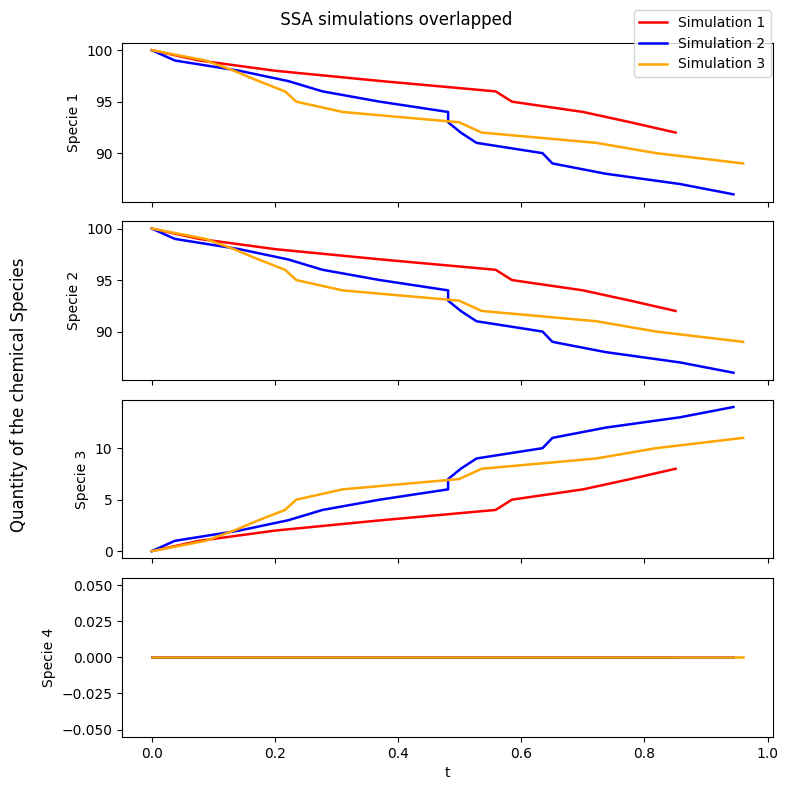

In [ ]:
## Plots to see the paths with given second setting in order to understand what kind of value pick for c_tilde for IS

# settings for this part
c = np.array([0.001, 0.005, 0.01])                  # constant values given in proj. descr.  
X = np.array([100, 100, 0, 0], dtype=int)           # initial states of the four species
t = 0                                               # initial time
T = 1  

n_sims = 3
sim_colors = ['r', 'b', 'orange']  

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8))

fig.supylabel("Quantity of the chemical Species")

for k in range(n_sims):
    X_try, t_try = simulation(sim_step_SSA, X, t, T, c, alpha, beta)

    t_plot = t_try[:-1] 
    X_plot = X_try[:-1, :]   


    for i in range(4):
        axes[i].plot(
            t_plot,
            X_plot[:, i],
            color=sim_colors[k],
            linewidth=1.8,
            label=f"Simulation {k+1}"
        )

# labels
for i in range(4):
    axes[i].set_ylabel(f"Specie {i+1}")
axes[-1].set_xlabel("t")

fig.suptitle(" SSA simulations overlapped")

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.99))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.tight_layout()
#plt.savefig("SSA_sim_2.png", dpi=300, bbox_inches="tight")
plt.show()

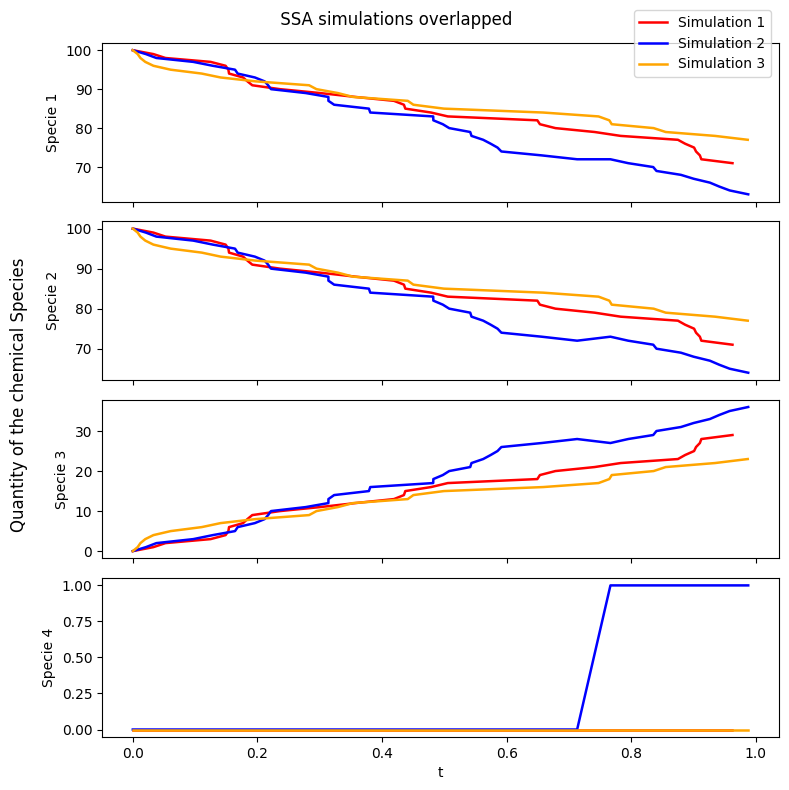

In [ ]:
## Plots to see the paths with NEW setting c_tilde 

# settings for this part
c = np.array([0.003, 0.01, 0.01])                  # changed c -> c_tilde  
X = np.array([100, 100, 0, 0], dtype=int)           # initial states of the four species
t = 0                                               # initial time
T = 1  

n_sims = 3
sim_colors = ['r', 'b', 'orange']  

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8))

fig.supylabel("Quantity of the chemical Species")

for k in range(n_sims):
    X_try, t_try = simulation(sim_step_SSA, X, t, T, c, alpha, beta)

    t_plot = t_try[:-1] 
    X_plot = X_try[:-1, :]   # (len(t_plot), 4)


    for i in range(4):
        axes[i].plot(
            t_plot,
            X_plot[:, i],
            color=sim_colors[k],
            linewidth=1.8,
            label=f"Simulation {k+1}"
        )

# labels
for i in range(4):
    axes[i].set_ylabel(f"Specie {i+1}")
axes[-1].set_xlabel("t")

fig.suptitle(" SSA simulations overlapped")

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.99))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.tight_layout()
#plt.savefig("SSA_sim_2_c_tilde.png", dpi=300, bbox_inches="tight")
plt.show()

### IS experiment (S-2.1/G-5)

In [ ]:
# settings for this part
c = np.array([0.001, 0.005, 0.01])                  # constant values given in proj. descr.  
X = np.array([100, 100, 0, 0], dtype=int)           # initial states of the four species
t = 0                                               # initial time
T = 1    

c_tilde = [0.0025, 0.01, 0.01]  #chosen to make the event X3(T)>22 more likely to observe 
sig_lev = 0.05
N=100000

Z_IS, var_Z_IS, CI_IS, obs = IS(c_tilde, sig_lev, S3_final_constraint, N, simulation, sim_step_SSA, X,t,T,c,alpha,beta)
print(Z_IS,var_Z_IS,CI_IS, obs)

2.6037094377635727e-05 4.985994708663801e-14 (np.float64(2.5609325418863482e-05), np.float64(2.646486333640797e-05)) 31130


# Section 3

## TL definition

In [6]:
## Section 3 - Tau Leaping algorithm (2)

def sim_step_TL(X,t,T,tau,c,alpha,beta):
    """
    input: 
        X       : current states (vector of dim=num_species) 
        t       : initial time
        T       : final time (last t is > T) 
        tau     : time step
        c       : (vector of constants with dim=num_reactions) 
        alpha   : (coeff of the left side of the system)
        beta    : (coeff of the right side of the system)
    output: 
        X_next  : states after one step(vector of dim=num_reactions) 
        t_next  : time at which next reaction happen
    explanation: 
        do a step of the simulation accordingly to Algorithm 2 (Tau Leaping) of proj. descr.
    """

    a = propensity(X,c,alpha)
    a_sum = sum(a)
    if a_sum == 0:
        ### comment the print when running multiple simulations for estimations ###
        #print(f"At this this state, no reaction can happen. Equilibrium reached at time {t}")
        return X, T   
    
    p = np.random.poisson(a*tau)
    nu = beta-alpha
    delta_X = p @ nu

    # take max wr 0 because doing only one big jump for all reactions we could get negative states
    X_next = np.maximum(X+delta_X, 0)
    t_next = t + tau

    return X_next, t_next

##

### Plots with TL (S-3.1.1/G-2)

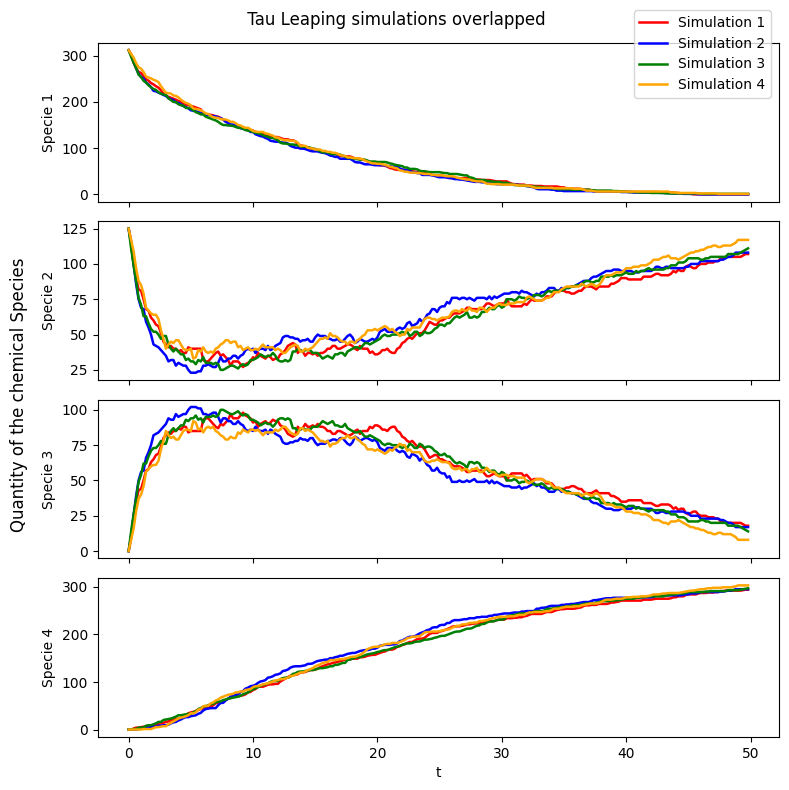

In [ ]:
## Section 3.1.1 goal 2

# general setting of the system 
alpha = np.array([[1,1,0,0],[0,0,1,0],[0,0,1,0]])   # values from the physical system
beta = np.array([[0,0,1,0],[1,1,0,0],[0,1,0,1]])    # values from the physical system
#

# setting for part 3.1.1 goal 2
c = np.array([0.0017, 10**-4, 0.1])                 # constant values given in proj. descr.  
X = np.array([312, 125, 0, 0], dtype=int)           # initial states of the four species
t = 0                                               # initial time
T = 50                                              # final time
tau = 0.2                                           # time step
#

# plot of some simulation with explicit Tau Leaping algorithm 
n_sims = 4
sim_colors = ['r', 'b', 'g', 'orange']  

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8))

fig.supylabel("Quantity of the chemical Species")

for k in range(n_sims):
    X_try, t_try = simulation(sim_step_TL, X, t, T, tau, c, alpha, beta)

    t_plot = t_try[:-1]
    X_plot = X_try[:-1, :]   

    for i in range(4):
        axes[i].plot(
            t_plot,
            X_plot[:, i],
            color=sim_colors[k],
            linewidth=1.8,
            label=f"Simulation {k+1}"
        )

# labels
for i in range(4):
    axes[i].set_ylabel(f"Specie {i+1}")
axes[-1].set_xlabel("t")

fig.suptitle(" Tau Leaping simulations overlapped")

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.99))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.tight_layout()
plt.savefig("TL_sim.png", dpi=300, bbox_inches="tight")
plt.show()

### CMC experiments (S-3.1.1/G-3)

In [ ]:
## section 3.1.1 goal 3

sig_lev = 0.05          # fixed
N = 1000
N_steps = 1
max_N = 10000           # to avoid infinite loop
eps = 1                 # threshold for half-width of the confidence interval
half_width_CI = eps+1
tau = 0.2

while half_width_CI > eps and N < max_N:
    Z, var_z, CI, _ = CMC(sig_lev, S4_final, N, simulation, sim_step_TL, X, t, T, tau, c, alpha, beta)
    half_width_CI = (CI[1]-CI[0])/2
    N += N_steps

print(f"Z=E[S4(T)]={Z} with CI=({CI[0]},{CI[1]}) and Var(Z)={var_z} after N={N-N_steps} simulations")

##

Z=E[S4(T)]=296.514 with CI=(296.26232740342977,296.76567259657025) and Var(Z)=0.01648829229229229 after N=1000 simulations


In [ ]:
# Produce values of the estimator with its CI w.r. N for the plot

sig_lev = 0.05          
tau = 0.2           #fixed

N_big_max = 1000      
N_big_step = 50       
N_tol = 50

N_big_hist_ETL = []
Z_big_hist_ETL = []
CI_big_lo_ETL = []
CI_big_hi_ETL = []

for N_big in range(N_tol, N_big_max + 1, N_big_step):
    Zb, varb, CIb, _ = CMC(sig_lev, S4_final, N_big, simulation, sim_step_TL, X, t, T, tau, c, alpha, beta)

    N_big_hist_ETL.append(N_big)
    Z_big_hist_ETL.append(Zb)
    CI_big_lo_ETL.append(CIb[0])
    CI_big_hi_ETL.append(CIb[1])


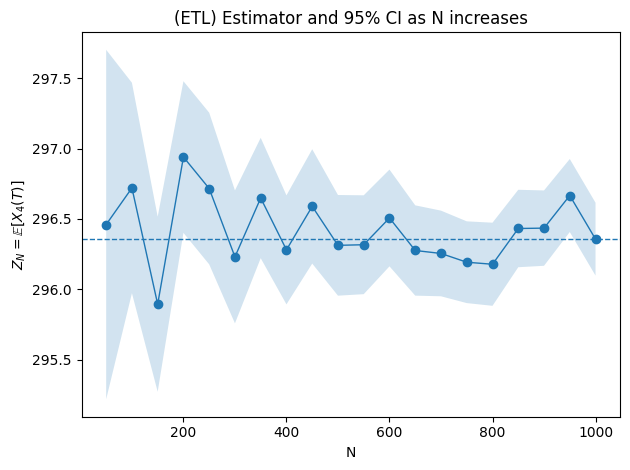

In [26]:

# plot of the estimator vs large N
N_big_arr_ETL = np.array(N_big_hist_ETL)
Z_big_arr_ETL = np.array(Z_big_hist_ETL)
CI_big_lo_arr_ETL = np.array(CI_big_lo_ETL)
CI_big_hi_arr_ETL = np.array(CI_big_hi_ETL)

plt.figure()
plt.plot(N_big_arr_ETL, Z_big_arr_ETL, marker='o', linewidth=1)
plt.fill_between(N_big_arr_ETL, CI_big_lo_arr_ETL, CI_big_hi_arr_ETL, alpha=0.2)
plt.axhline(Z_big_arr_ETL[-1], linewidth=1, linestyle='--')  # last value as reference
plt.xlabel("N")
plt.ylabel(r"$ Z_N = {\mathbb{E}}[X_4(T)]$")
plt.title("(ETL) Estimator and 95% CI as N increases")
plt.tight_layout()
plt.savefig("ETL_MC_vs_N.png", dpi=300, bbox_inches="tight")
plt.show()


## Implicit TL definition

In [ ]:
## functions definitions for the Implicit Tau Leaping Algorithm

def continuous_propensity(X,c,alpha):
    """
    input: 
        X       : current states (vector of floats of dim=num_species)
        c       : (vector of constants with dim=num_reactions)
        alpha   : (coeff of the left side of the system).
    output: 
        a       : propensity function (vector of dim=num_reactions)
    explanation:  
        compute the formula given in the project description but for float inputs. Needed for 
        the Newton method since we need a differentiable function to apply it.
    """

    a = np.array(c)
    for j in range(0,len(c)):
        for i in range(0,len(X)):
            if X[i]>=alpha[j][i]:
                for r in range(0,alpha[j][i]):
                    a[j] = a[j]*(X[i]-r) 
            else:
                a[j] = 0    
    return a

def function_for_newton(y,X,tau,c,alpha,beta):
    """
    input: 
        y               : state X(t)+tau*a(y)@nu (vector dim=num_species)
        X               : current states (vector of dim=num_species) 
        tau             : time step
        c               : (vector of constants with dim=num_reactions) 
        alpha           : (coeff of the left side of the system)
        beta            : (coeff of the right side of the system)
    output: 
        y-X-tau*drift   : function we need to make 0 trough newton method to find y 
    explanation: 
        compute the non linear function to be solved through newton method for the Implicit
        Tau Leaping algorithm
    """
    nu = beta-alpha
    a = continuous_propensity(y,c,alpha)
    drift = a@nu
    return y - X - tau*drift

"""
This commented function below was the first function for newton method but for larger tau it didn't converge.
To our understanding of the problems, the root function could make trials with negative values and the 
initial try might be too far from the actual solution. Moreover, bigger tau might imply almost singular Jacobian
which produces bigger newton steps that could diverge. 
Therefore, we wrote the other uncommented function with a different solver, with the constraint of non negative
components and a better initialization. 

def solve_implicit_y(X,tau,c,alpha,beta):
    y0 = np.array(X)
    sol = so.root(function_for_newton, y0, args=(X,tau,c,alpha,beta), method="hybr")
    if not sol.success : 
        raise RuntimeError("Newton/root do not converge: " + sol.message)
    return sol.x
"""

# another version for numerical stability BUT MUCH SLOWER-use the other for tau<=0.2
def solve_implicit_y(X,tau,c,alpha,beta):
    """
    input:
        X       : current state at time t (vector of length = num_species).
        tau     : time step size.
        c       : reaction rate constants (vector of length = num_reactions).
        alpha   : stoichiometric coefficients of reactants (matrix num_reactions x num_species).
        beta    : stoichiometric coefficients of products  (matrix num_reactions x num_species).
    output:
        y       : implicit intermediate state (vector of floats of length = num_species)
                  solving y - X - tau * (a(y) @ (beta-alpha)) = 0.
    explanation:
        This function computes the intermediate value y required by the Implicit Tau-Leaping method.
        The value y is defined implicitly by a nonlinear system, which we solve numerically.

        Compared to a standard root-finding call, we use a more robust least-squares solver with
        non-negativity bounds (y >= 0) to avoid non-physical intermediate states that often cause
        convergence issues for large tau. We also use a better initial guess y0 obtained from an
        explicit drift step, y0 = X + tau*(a(X)@nu), and then clipped to be non-negative. This
        combination typically improves numerical stability and reduces failures of the solver.
    """
    X = np.asarray(X, dtype=float)
    nu = beta - alpha
    # better initial guess: explicit drift step (mean-field)
    aX = continuous_propensity(np.maximum(X, 0.0), c, alpha)
    y0 = np.maximum(X + tau * (aX @ nu), 0.0)
    sol = so.least_squares(
        function_for_newton,
        y0,
        bounds=(0.0, np.inf),     # enforce non-negativity
        args=(X, tau, c, alpha, beta),
        max_nfev=2000
    )
    if not sol.success : 
        raise RuntimeError("Newton/root do not converge: " + sol.message)
    return sol.x


def sim_step_ITL(X,t,T,tau,c,alpha,beta):
    """
    input: 
        X       : current states (vector of dim=num_species) 
        t       : initial time
        T       : final time (last t is > T) 
        tau     : time step
        c       : (vector of constants with dim=num_reactions) 
        alpha   : (coeff of the left side of the system)
        beta    : (coeff of the right side of the system)
    output: 
        X_next  : states after one step(vector of dim=num_reactions) 
        t_next  : time at which next reaction happen
    explanation: 
        do a step of the simulation accordingly to Algorithm of Implicit Tau Leaping of proj. descr.
        section 3.1.1 goal 4. 
        N.B. Even if we compute "a" with continuous_propensity (so as a vector of float numbers), 
        the final vector state will be of integers since a is used only as an argument of the poisson
        distribution, from which we sample integers.
    """
    y = solve_implicit_y(X,tau,c,alpha,beta)
    a = continuous_propensity(y,c,alpha)
    a_sum = sum(a)
    if a_sum == 0:
        ### comment the print when running multiple simulations for estimations ###
        #print(f"At this this state, no reaction can happen. Equilibrium reached at time {t}")
        return X, T   
    
    p = np.random.poisson(a*tau)
    nu = beta-alpha
    delta_X = p @ nu
    delta_X = np.array(delta_X, dtype=int)

    # take max wr 0 because doing only one big jump for all reactions we could get negative states
    X_next = np.maximum(X+delta_X, 0)
    t_next = t + tau

    return X_next, t_next

##

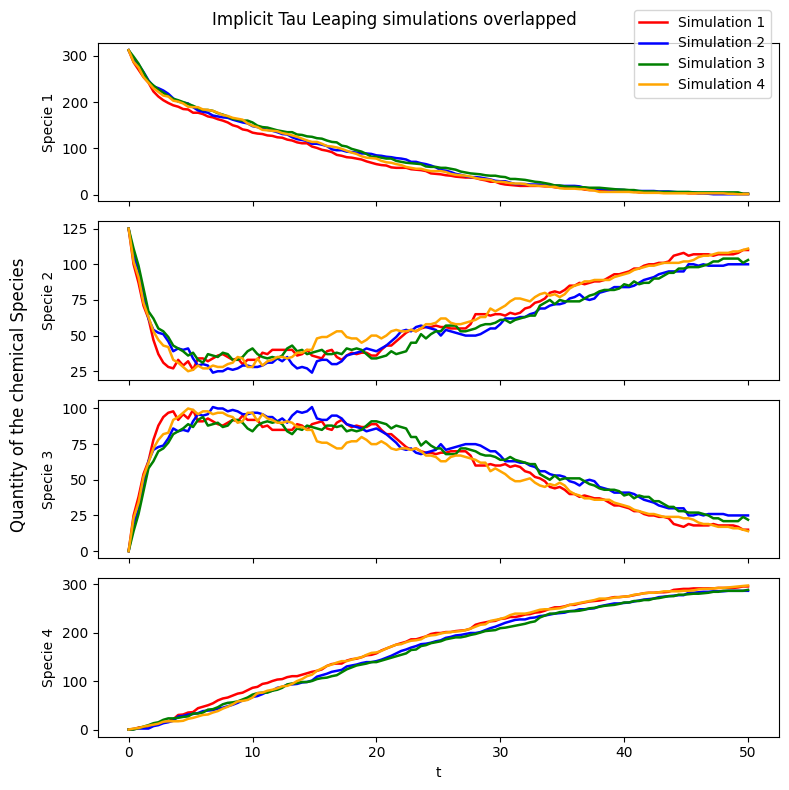

In [ ]:
# plot of some simulation with Implicit Tau Leaping algorithm (Just to see if it makes sense) 

n_sims = 4
sim_colors = ['r', 'b', 'g', 'orange']  

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8))

fig.supylabel("Quantity of the chemical Species")

for k in range(n_sims):
    X_try, t_try = simulation(sim_step_ITL, X, t, T, tau, c, alpha, beta)

    t_plot = t_try[:-1]
    X_plot = X_try[:-1, :]   

    for i in range(4):
        axes[i].plot(
            t_plot,
            X_plot[:, i],
            color=sim_colors[k],
            linewidth=1.8,
            label=f"Simulation {k+1}"
        )

# labels
for i in range(4):
    axes[i].set_ylabel(f"Specie {i+1}")
axes[-1].set_xlabel("t")

fig.suptitle("Implicit Tau Leaping simulations overlapped")

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.99))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.tight_layout()
#plt.savefig("ITL_sim.png", dpi=300, bbox_inches="tight")
plt.show()

### CMC experiments (S-3.1.1/G-4)

In [ ]:
## section 3.1.1 goal 4

sig_lev = 0.05          # fixed
N = 2
N_steps = 3
max_N = 10000           # to avoid infinite loop
eps = 1                 # threshold for half-width of the confidence interval
half_width_CI = eps+1
tau = 0.2

while half_width_CI > eps and N < max_N:
    Z, var_z, CI, _ = CMC(sig_lev, S4_final, N, simulation, sim_step_ITL, X, t, T, tau, c, alpha, beta)
    half_width_CI = (CI[1]-CI[0])/2
    N += N_steps

print(f"Z=E[S4(T)]={Z:.3f} with CI=({CI[0]:.3f},{CI[1]:.3f}) and Var(Z)={var_z:.4f} after N={N-N_steps} simulations")

##

Z=E[S4(T)]=295.234 with CI=(294.314,296.154) and Var(Z)=0.2204 after N=47 simulations


In [ ]:
# Produce values of the estimator with its CI w.r. N for the plot

sig_lev = 0.05          
tau = 0.2           #fixed

N_big_max = 1000      
N_big_step = 50       
N_tol = 950

N_big_hist_ITL = []
Z_big_hist_ITL = []
CI_big_lo_ITL = []
CI_big_hi_ITL = []

for N_big in range(N_tol, N_big_max + 1, N_big_step):
    Zb, varb, CIb, _ = CMC(sig_lev, S4_final, N_big, simulation, sim_step_ITL, X, t, T, tau, c, alpha, beta)

    N_big_hist_ITL.append(N_big)
    Z_big_hist_ITL.append(Zb)
    CI_big_lo_ITL.append(CIb[0])
    CI_big_hi_ITL.append(CIb[1])


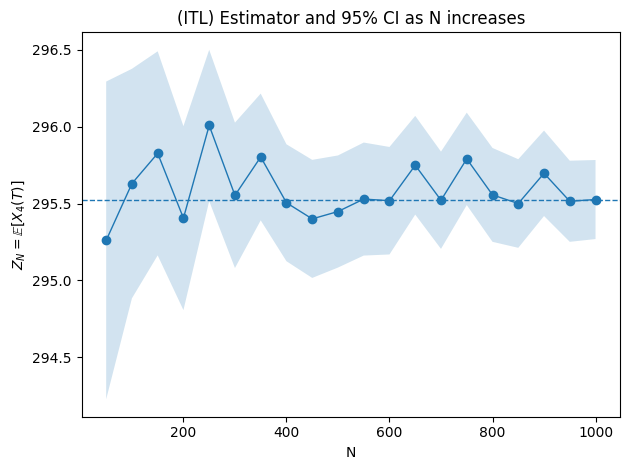

In [ ]:

# plot of the estimator vs N
N_big_arr_ITL = np.array(N_big_hist_ITL)
Z_big_arr_ITL = np.array(Z_big_hist_ITL)
CI_big_lo_arr_ITL = np.array(CI_big_lo_ITL)
CI_big_hi_arr_ITL = np.array(CI_big_hi_ITL)

plt.figure()
plt.plot(N_big_arr_ITL, Z_big_arr_ITL, marker='o', linewidth=1)
plt.fill_between(N_big_arr_ITL, CI_big_lo_arr_ITL, CI_big_hi_arr_ITL, alpha=0.2)
plt.axhline(Z_big_arr_ITL[-1], linewidth=1, linestyle='--')  # last value as reference
plt.xlabel("N")
plt.ylabel(r"$ Z_N = {\mathbb{E}}[X_4(T)]$")
plt.title("(ITL) Estimator and 95% CI as N increases")
plt.tight_layout()
plt.savefig("ITL_MC_vs_N.png", dpi=300, bbox_inches="tight")
plt.show()


## Euler-Maruyama discretization for Chemical-Langevin-Equation (S-3.2.1/G-2)

In [19]:
## function definition for the Euler-Maruyama scheme 

def sim_step_EM(X,t,T,tau,c,alpha,beta):
    """
    input: 
        X       : current states (vector of dim=num_species) 
        t       : initial time
        T       : final time (last t is > T) 
        tau     : time step
        c       : (vector of constants with dim=num_reactions) 
        alpha   : (coeff of the left side of the system)
        beta    : (coeff of the right side of the system)
    output: 
        X_next  : states after one step(vector of dim=num_reactions) 
        t_next  : time at which next reaction happen
    explanation: 
        do a step of the simulation accordingly to Euler-Maruyama scheme
    """

    a = continuous_propensity(X,c,alpha)
    a_sum = sum(a)
    if a_sum == 0:
        ### comment the print when running multiple simulations for estimations ###
        #print(f"At this this state, no reaction can happen. Equilibrium reached at time {t}")
        return X, T   
    
    z_vec = np.random.normal(0,1,size=len(a))
    nu = beta-alpha
    delta_X = tau*(a @ nu) + np.sqrt(tau)*((z_vec * np.sqrt(a)) @ nu )

    # take max wr 0 because doing only one big jump for all reactions we could get negative states
    X_next = np.abs(X+delta_X)
    t_next = t + tau

    return X_next, t_next

##

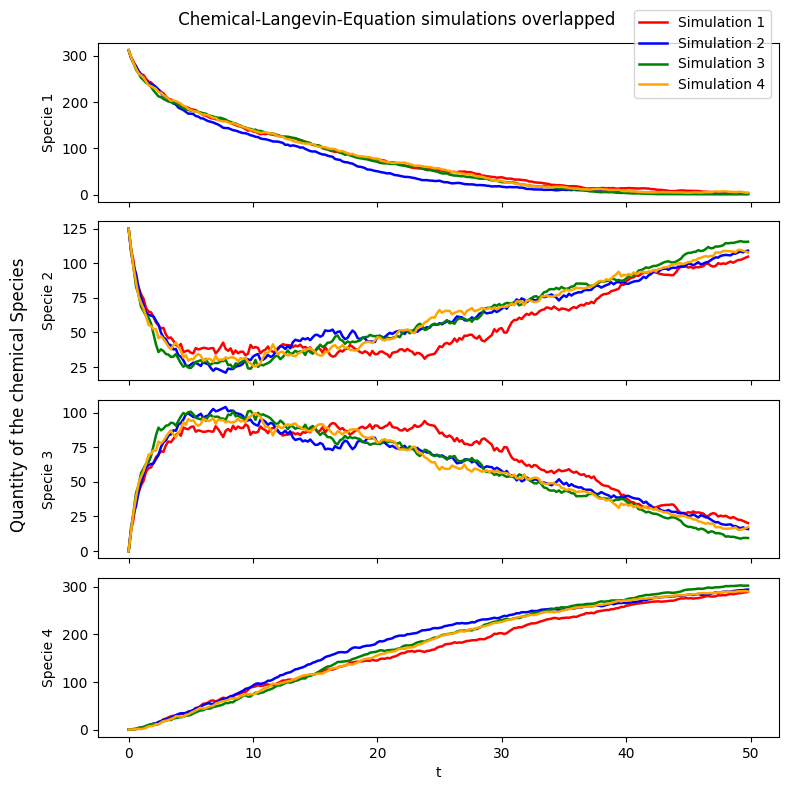

In [ ]:
# plot of some simulation with CLE algorithm + EM scheme

n_sims = 4
sim_colors = ['r', 'b', 'g', 'orange']  

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8))

fig.supylabel("Quantity of the chemical Species")

for k in range(n_sims):
    X_try, t_try = simulation(sim_step_EM, X, t, T, tau, c, alpha, beta)

    t_plot = t_try[:-1]
    X_plot = X_try[:-1, :]   

    for i in range(4):
        axes[i].plot(
            t_plot,
            X_plot[:, i],
            color=sim_colors[k],
            linewidth=1.8,
            label=f"Simulation {k+1}"
        )

# labels
for i in range(4):
    axes[i].set_ylabel(f"Specie {i+1}")
axes[-1].set_xlabel("t")

fig.suptitle(" Chemical-Langevin-Equation simulations overlapped")

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.99))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.tight_layout()
#plt.savefig("EM_sim.png", dpi=300, bbox_inches="tight")
plt.show()

### CMC experiments (S-3.2.1/G-3)

In [ ]:
## section 3.2.1 goal 3

sig_lev = 0.05          # fixed
N = 10
N_steps = 1
max_N = 10000           # to avoid infinite loop
eps = 1                 # threshold for half-width of the confidence interval
half_width_CI = eps+1
tau = 0.2


while half_width_CI > eps and N < max_N:
    Z, var_z, CI, _ = CMC(sig_lev, S4_final, N, simulation, sim_step_EM, X, t, T, tau, c, alpha, beta)
    half_width_CI = (CI[1]-CI[0])/2
    N += N_steps

print(f"Z=E[S4(T)]={Z:.3f} with CI=({CI[0]:.3f},{CI[1]:.3f}) and Var(Z)={var_z:.4f} after N={N-N_steps} simulations")

##

Z=E[S4(T)]=296.420 with CI=(295.461,297.378) and Var(Z)=0.2392 after N=59 simulations


In [ ]:
# Produce values of the estimator with its CI w.r. N for the plot

sig_lev = 0.05          
tau = 0.2               #fixed

N_big_max = 1000      
N_big_step = 50       
N_tol = 50

N_big_hist_CLE = []
Z_big_hist_CLE = []
CI_big_lo_CLE = []
CI_big_hi_CLE = []

for N_big in range(N_tol, N_big_max + 1, N_big_step):
    Zb, varb, CIb, _ = CMC(sig_lev, S4_final, N_big, simulation, sim_step_EM, X, t, T, tau, c, alpha, beta)

    N_big_hist_CLE.append(N_big)
    Z_big_hist_CLE.append(Zb)
    CI_big_lo_CLE.append(CIb[0])
    CI_big_hi_CLE.append(CIb[1])


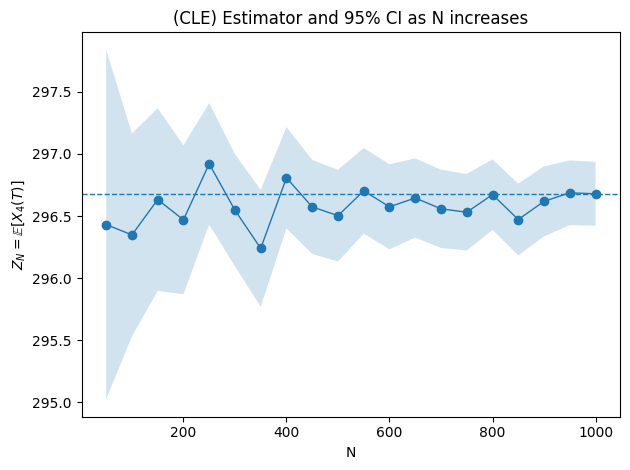

In [ ]:

# plot of the estimator vs N
N_big_arr_CLE = np.array(N_big_hist_CLE)
Z_big_arr_CLE = np.array(Z_big_hist_CLE)
CI_big_lo_arr_CLE = np.array(CI_big_lo_CLE)
CI_big_hi_arr_CLE = np.array(CI_big_hi_CLE)

plt.figure()
plt.plot(N_big_arr_CLE, Z_big_arr_CLE, marker='o', linewidth=1)
plt.fill_between(N_big_arr_CLE, CI_big_lo_arr_CLE, CI_big_hi_arr_CLE, alpha=0.2)
plt.axhline(Z_big_arr_CLE[-1], linewidth=1, linestyle='--')  # last value as reference
plt.xlabel("N")
plt.ylabel(r"$ Z_N = {\mathbb{E}}[X_4(T)]$")
plt.title("(CLE) Estimator and 95% CI as N increases")
plt.tight_layout()
plt.savefig("CLE_MC_vs_N.png", dpi=300, bbox_inches="tight")
plt.show()
